## ThinkDSP

This notebook contains code examples from Chapter 2: Harmonics

Copyright 2015 Allen Downey

License: [Creative Commons Attribution 4.0 International](http://creativecommons.org/licenses/by/4.0/)

In [ ]:
from os.path import basename, exists

def download(url):
    filename = basename(url)
    if not exists(filename):
        from urllib.request import urlretrieve
        local, _ = urlretrieve(url, filename)
        print("Downloaded " + local)

download("https://github.com/AllenDowney/ThinkDSP/raw/master/thinkdsp/thinkdsp.py")


## Waveforms and harmonics

Create a triangle signal and plot a 3 period segment.

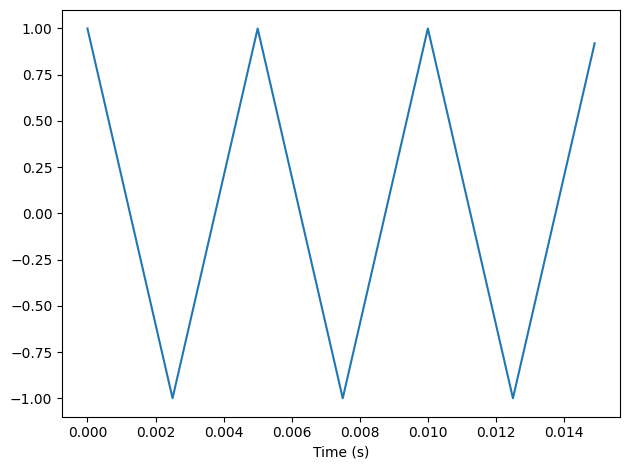

In [ ]:
from thinkdsp import TriangleSignal
from thinkdsp import decorate

signal = TriangleSignal(200)
duration = signal.period*3
segment = signal.make_wave(duration, framerate=10000)
segment.plot()
decorate(xlabel='Time (s)')

Make a wave and play it.

In [ ]:
wave = signal.make_wave(duration=0.5, framerate=40000)
wave.apodize()
wave.make_audio()

Compute its spectrum and plot it.

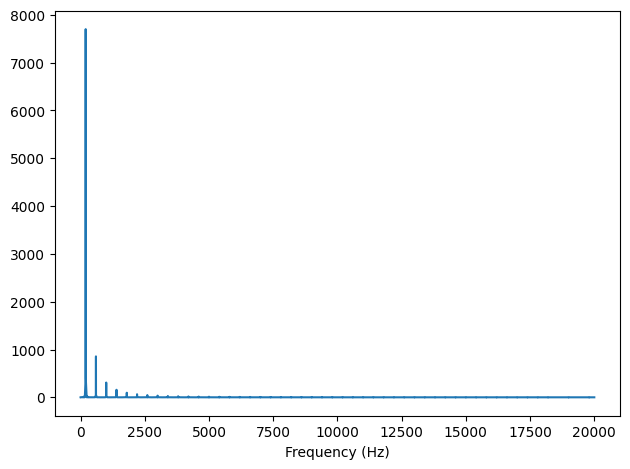

In [ ]:
spectrum = wave.make_spectrum()
spectrum.plot()
decorate(xlabel='Frequency (Hz)')

Make a square signal and plot a 3 period segment.

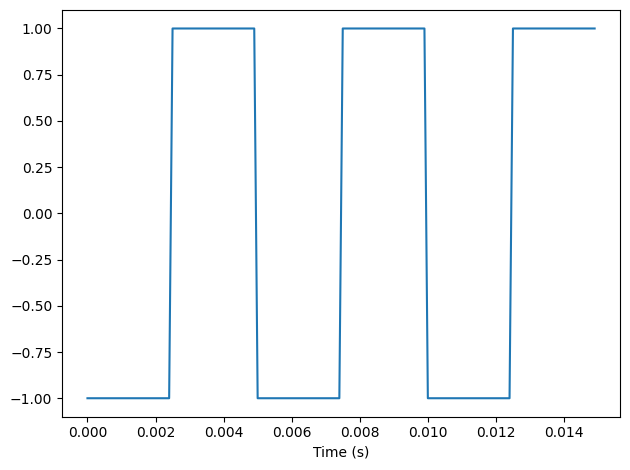

In [ ]:
from thinkdsp import SquareSignal

signal = SquareSignal(200)
duration = signal.period*3
segment = signal.make_wave(duration, framerate=10000)
segment.plot()
decorate(xlabel='Time (s)')

Make a wave and play it.

In [ ]:
wave = signal.make_wave(duration=0.5, framerate=10000)
wave.apodize()
wave.make_audio()

Compute its spectrum and plot it.

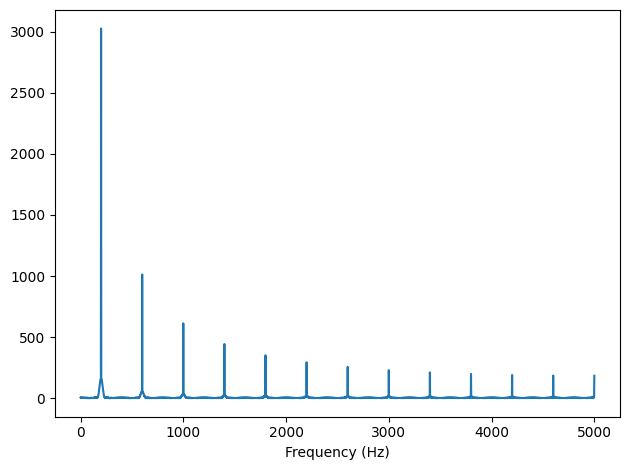

In [ ]:
spectrum = wave.make_spectrum()
spectrum.plot()
decorate(xlabel='Frequency (Hz)')

Create a sawtooth signal and plot a 3 period segment.

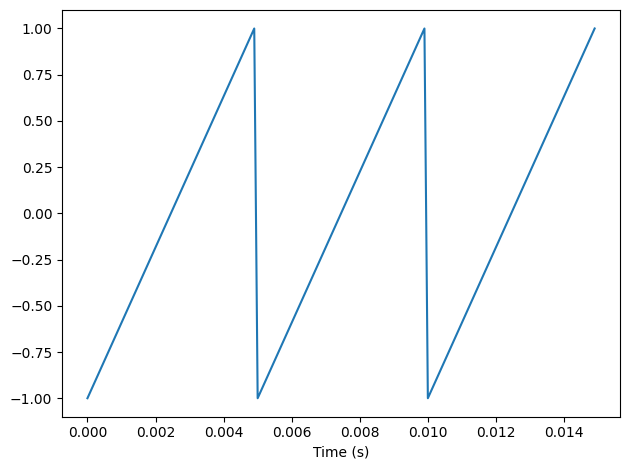

In [ ]:
from thinkdsp import SawtoothSignal

signal = SawtoothSignal(200)
duration = signal.period*3
segment = signal.make_wave(duration, framerate=10000)
segment.plot()
decorate(xlabel='Time (s)')

Make a wave and play it.

In [ ]:
wave = signal.make_wave(duration=0.5, framerate=10000)
wave.apodize()
wave.make_audio()

Compute its spectrum and plot it.

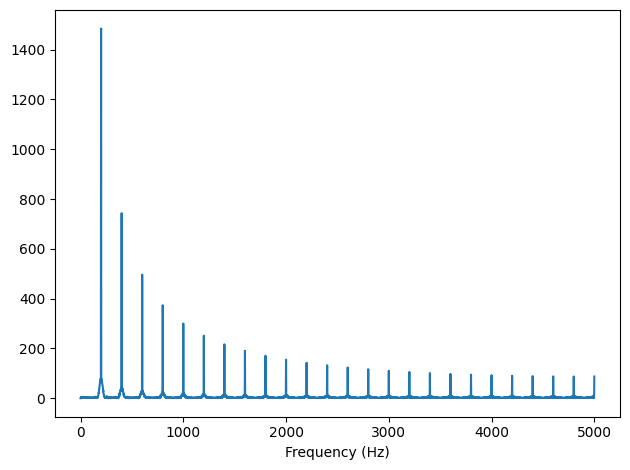

In [ ]:
spectrum = wave.make_spectrum()
spectrum.plot()
decorate(xlabel='Frequency (Hz)')

### Aliasing

Make a cosine signal at 4500 Hz, make a wave at framerate 10 kHz, and plot 5 periods.

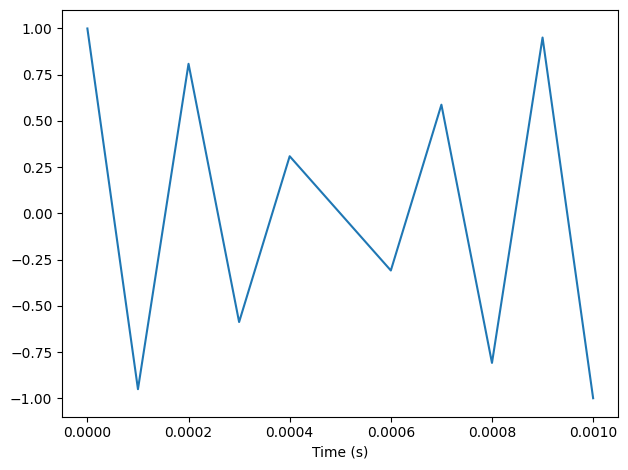

In [ ]:
from thinkdsp import CosSignal

signal = CosSignal(4500)
duration = signal.period*5
segment = signal.make_wave(duration, framerate=10000)
segment.plot()
decorate(xlabel='Time (s)')

Make a cosine signal at 5500 Hz, make a wave at framerate 10 kHz, and plot the same duration.

With framerate 10 kHz, the folding frequency is 5 kHz, so a 4500 Hz signal and a 5500 Hz signal look exactly the same.

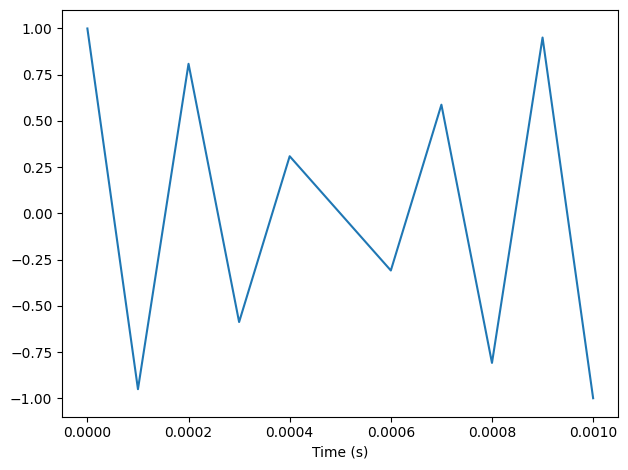

In [ ]:
signal = CosSignal(5500)
segment = signal.make_wave(duration, framerate=10000)
segment.plot()
decorate(xlabel='Time (s)')

Make a triangle signal and plot the spectrum.  See how the harmonics get folded.

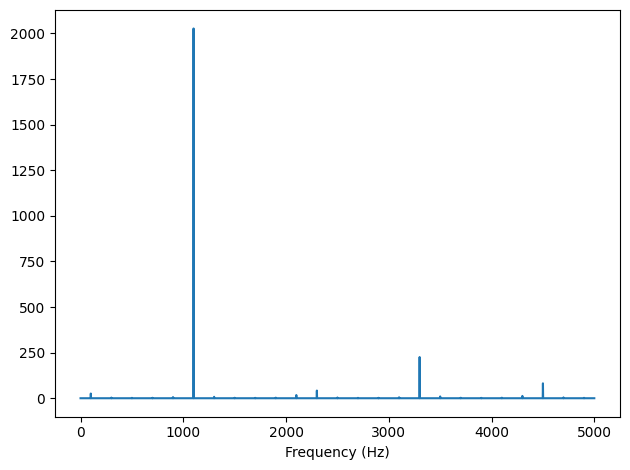

In [ ]:
signal = TriangleSignal(1100)
segment = signal.make_wave(duration=0.5, framerate=10000)
spectrum = segment.make_spectrum()
spectrum.plot()
decorate(xlabel='Frequency (Hz)')

## Amplitude and phase

Make a sawtooth wave.

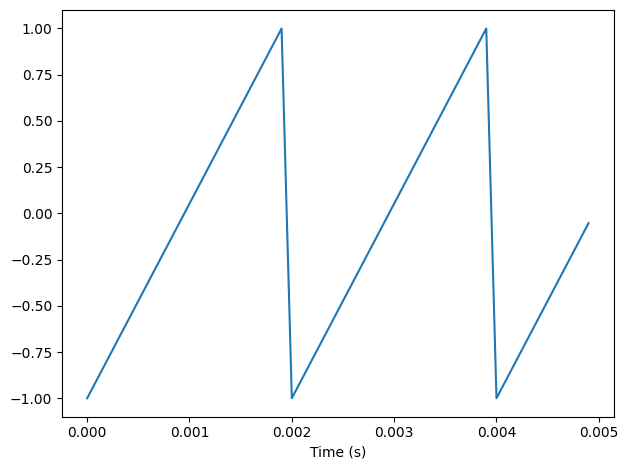

In [ ]:
signal = SawtoothSignal(500)
wave = signal.make_wave(duration=1, framerate=10000)
segment = wave.segment(duration=0.005)
segment.plot()
decorate(xlabel='Time (s)')

Play it.

In [ ]:
wave.make_audio()

Extract the wave array and compute the real FFT (which is just an FFT optimized for real inputs).

In [ ]:
import numpy as np

hs = np.fft.rfft(wave.ys)
hs

array([ 5.11590770e-13+0.00000000e+00j,  2.19700679e-13-1.34559298e-13j,
       -2.09548671e-13-6.74603523e-14j, ...,
        4.19606174e-13+3.46000979e-14j, -5.63280756e-13+5.74915022e-14j,
       -5.26315789e+02+0.00000000e+00j])

Compute the frequencies that match up with the elements of the FFT.

In [ ]:
n = len(wave.ys)                 # number of samples
d = 1 / wave.framerate           # time between samples
fs = np.fft.rfftfreq(n, d)
fs

array([0.000e+00, 1.000e+00, 2.000e+00, ..., 4.998e+03, 4.999e+03,
       5.000e+03])

Plot the magnitudes vs the frequencies.

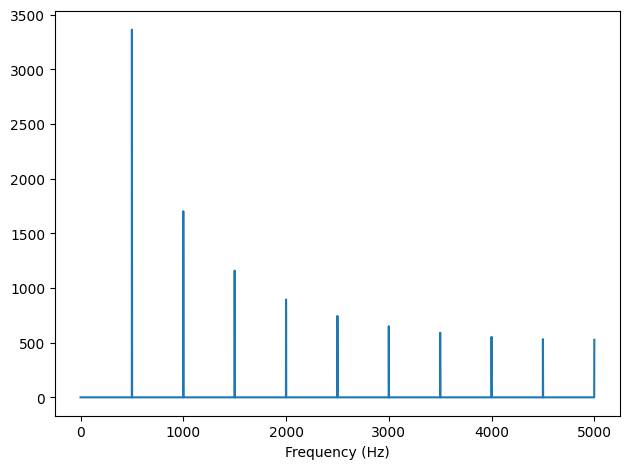

In [ ]:
import matplotlib.pyplot as plt

magnitude = np.absolute(hs)
plt.plot(fs, magnitude)
decorate(xlabel='Frequency (Hz)')

Plot the phases vs the frequencies.

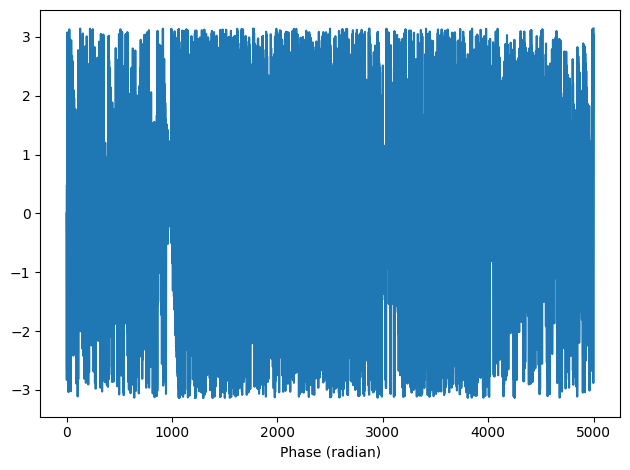

In [ ]:
angle = np.angle(hs)
plt.plot(fs, angle)
decorate(xlabel='Phase (radian)')

## What does phase sound like?

Shuffle the phases.

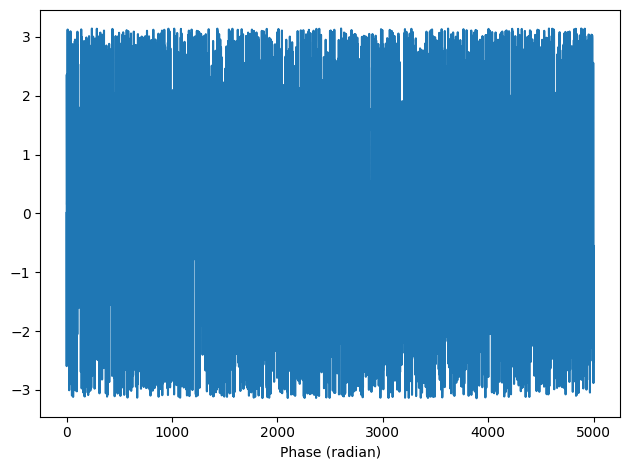

In [ ]:
import random
random.shuffle(angle)
plt.plot(fs, angle)
decorate(xlabel='Phase (radian)')

Put the shuffled phases back into the spectrum.  Each element in `hs` is a complex number with magitude $A$ and phase $\phi$, with which we can compute $A e^{i \phi}$

In [ ]:
i = complex(0, 1)
spectrum = wave.make_spectrum()
spectrum.hs = magnitude * np.exp(i * angle)

Convert the spectrum back to a wave (which uses irfft).

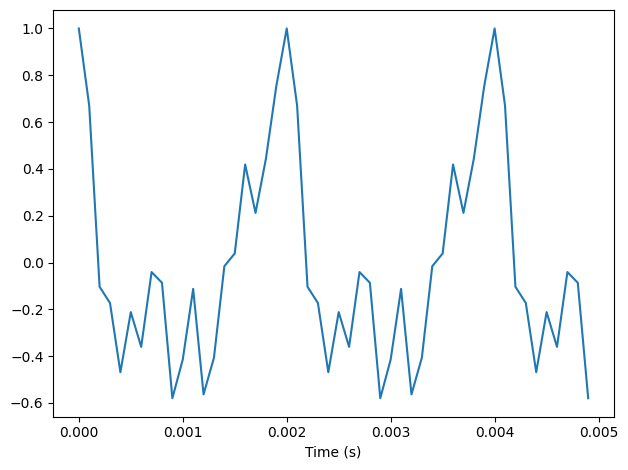

In [ ]:
wave2 = spectrum.make_wave()
wave2.normalize()
segment = wave2.segment(duration=0.005)
segment.plot()
decorate(xlabel='Time (s)')

Play the wave with the shuffled phases.

In [ ]:
wave2.make_audio()

For comparison, here's the original wave again.

In [ ]:
wave.make_audio()

Although the two signals have different waveforms, they have the same frequency components with the same amplitudes.  They differ only in phase.

## Aliasing interaction

The following interaction explores the effect of aliasing on the harmonics of a sawtooth signal.

In [ ]:
def view_harmonics(freq, framerate):
    """Plot the spectrum of a sawtooth signal.

    freq: frequency in Hz
    framerate: in frames/second
    """
    signal = SawtoothSignal(freq)
    wave = signal.make_wave(duration=0.5, framerate=framerate)
    spectrum = wave.make_spectrum()
    spectrum.plot(color='C0')
    decorate(xlabel='Frequency (Hz)', ylabel='Amplitude')
    display(wave.make_audio())

In [ ]:
from ipywidgets import interact, interactive, fixed
import ipywidgets as widgets

slider1 = widgets.FloatSlider(min=100, max=10000, value=100, step=100)
slider2 = widgets.FloatSlider(min=5000, max=40000, value=10000, step=1000)
interact(view_harmonics, freq=slider1, framerate=slider2);

interactive(children=(FloatSlider(value=100.0, description='freq', max=10000.0, min=100.0, step=100.0), FloatS…

#2.2


In [1]:

import numpy as np
from thinkdsp import Sinusoid, normalize, unbias

class SawtoothSignal(Sinusoid):
    """Represents a sawtooth signal."""

    def evaluate(self, ts):
        """Evaluates the signal at the given times.
        ts: float array of times
        returns: float wave array

        """

        # time of a sample to an array of the ycle numebr compelted by that time
        cycles = self.freq * ts + self.offset / 2 / np.pi
        frac, _ = np.modf(cycles)
        ys = normalize(unbias(frac), self.amp)

        return ys
        #
        # normalize centering it at 1






ModuleNotFoundError: No module named 'thinkdsp'

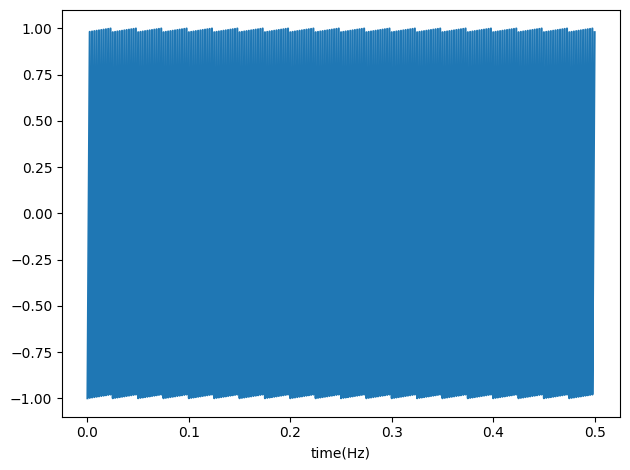

In [ ]:
saw = SawtoothSignal().make_wave(duration=0.5, framerate= 40000)
saw.plot()
decorate(xlabel='time(Hz)')
saw.make_audio()

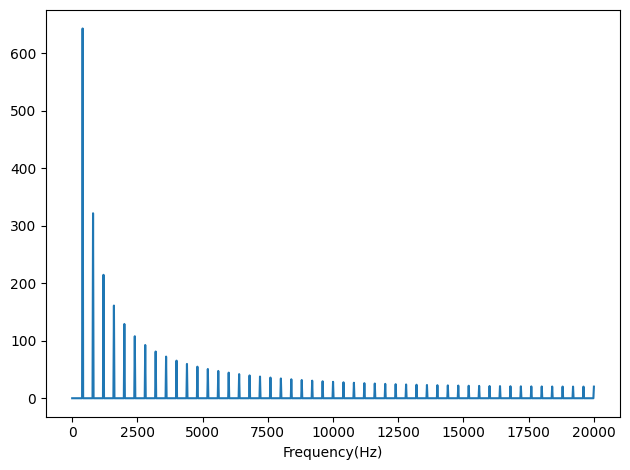

In [ ]:
spectrum = saw.make_spectrum()
spectrum.plot()
decorate(xlabel='Frequency(Hz)')

We see peaks at multiples of the fundemental frequency both even and odd. Another thing that the booked looked at that I didn't notice. The ratio between the peaks in terms of amplitude.

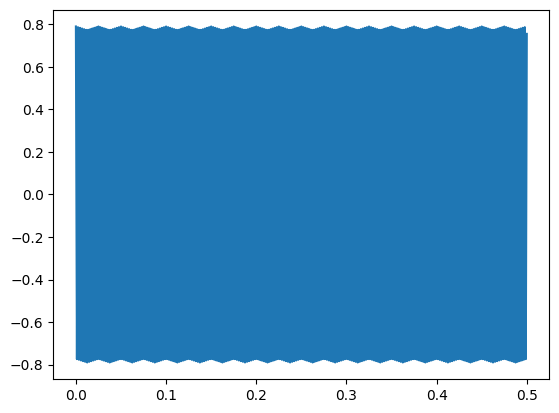

In [ ]:
from thinkdsp import TriangleSignal, SquareSignal

triangle = TriangleSignal(amp=0.79).make_wave(duration=0.5, framerate= 40000)
triangle.plot()

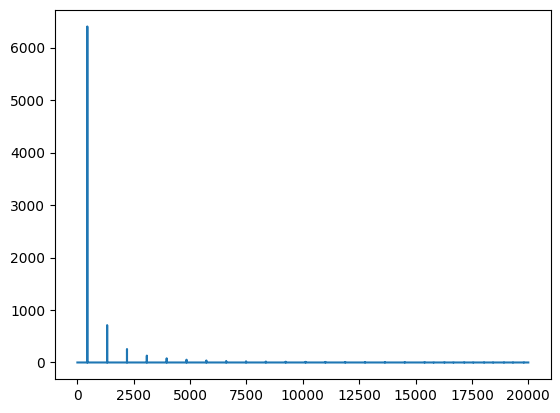

In [ ]:
trianglespec = triangle.make_spectrum()
trianglespec.plot()

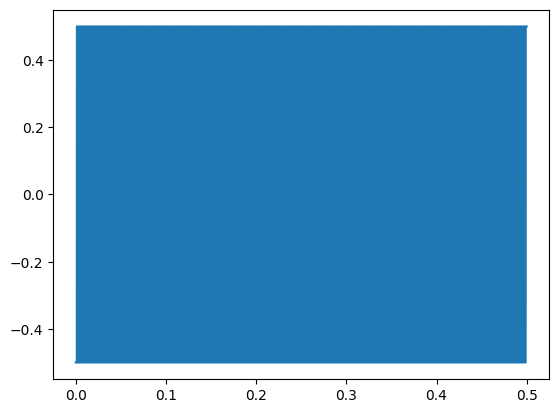

In [ ]:
square = SquareSignal(amp=0.5).make_wave(duration=0.5, framerate= 40000)
square.plot()

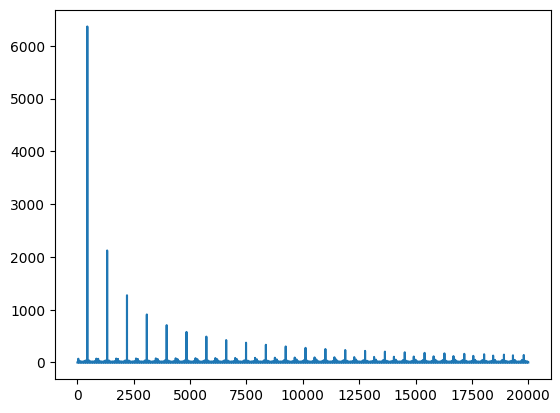

In [ ]:
squarespec = square.make_spectrum()
squarespec.plot()

Observation: the harmonic structure/ampltiude ratio is 1/f for square, similar to sawtooth. Whereas for triangle its roughly 1/f^2.

# 2.3

### Make a square signal at 1100 Hz an amke a wave that smaples it at 10000 frames per second. If you plot the spectru, you can see that most of the harmonics are aliased. When you listen to the wave, can you hear the aliased harmonics

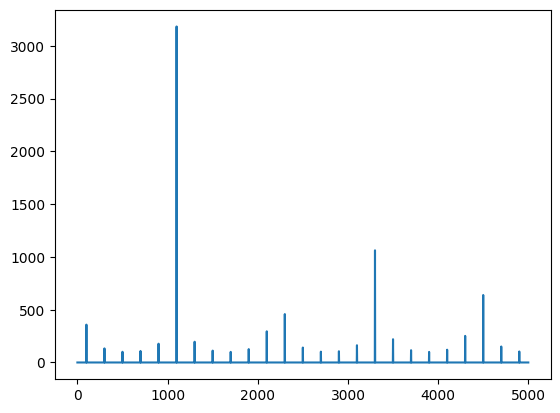

In [ ]:
square = SquareSignal(1100).make_wave(duration=0.5, framerate=10000)
squareSpec = square.make_spectrum()
squareSpec.plot()
square.make_audio()

I hear this higher frequency and also that low frequency at 1100 which I guess is the fundamental. The fundamentals are 1100, 3300, and you expect 5500 to be the next one but it rolls over to 4500. YOu also see peaks at 2300 which would not expect.

In [ ]:
sinwave = Sinusoid(1100).make_wave(duration=0.5, framerate=10000)
sinwave.make_audio()

#2.4

(1.0436096431476471e-14+0j)


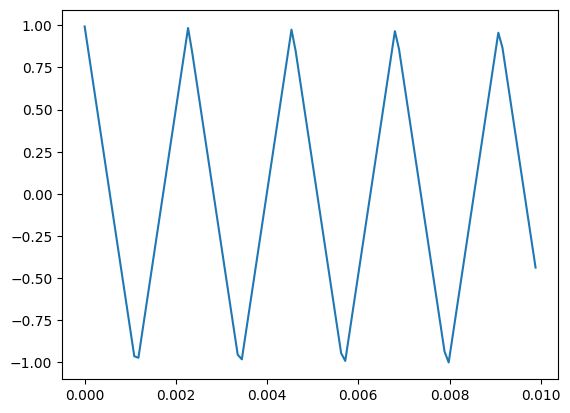

In [ ]:
triangle =  TriangleSignal(440).make_wave(duration=0.01)
spec = triangle.make_spectrum()
print(spec.hs[0])
triangle.plot()

Only has a real compoennet = 6.661338147750939e-16+. No phase offset angle is 0.

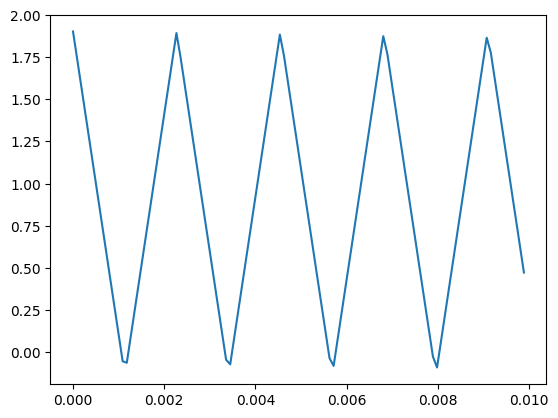

In [ ]:
spec.hs[0] = 100

new_wave = spec.make_wave()
new_wave.plot()

The affect is that the amplitude of the wave is increased. Essentially multiplied by a factor of 1.

#2.5

In [ ]:
def spectrumModifier(spec):

    spec.hs[0] = 0

    spec.hs[1:] /= spec.fs[1:]


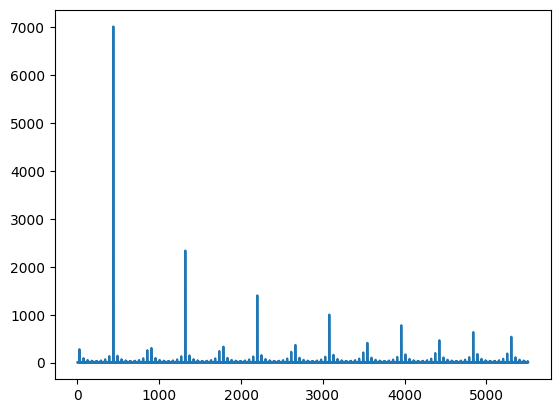

In [ ]:
square = SquareSignal(440).make_wave()

square_spec = square.make_spectrum()
square_spec.plot()

square.make_audio()

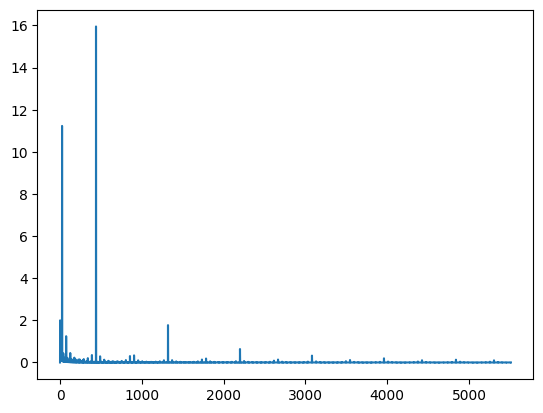

In [ ]:
spectrumModifier(square_spec)
square_spec.plot()
square_spec.make_wave().make_audio()

Dividing by the corresponding frequency scales down the magnitudes which essentially makes the wave inaudible.

#2.6

<!-- find a waveform taht has even and odd harmonics that drop off like 1/f2.  -->


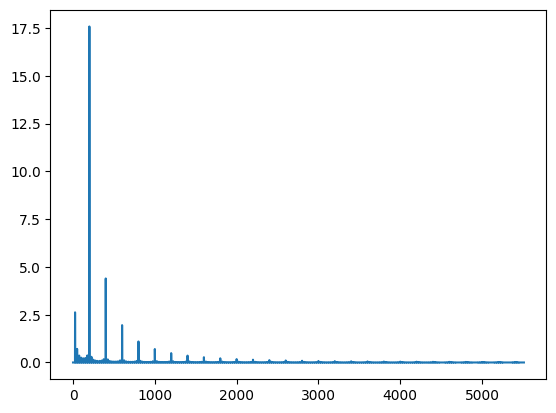

In [ ]:
modified = SawtoothSignal(200).make_wave().make_spectrum()

modified.hs[1:] /= modified.fs[1:]

modified.plot()



WRONG::: Frequency is roughly doubled but amplitude dorps by 1/4. Walk through the logic here what characteristics you had what did you wnat. SO bascially you take the sawtooth which you know has even and odd harmonics at f0, 2f0, 3f0, 4f0. But currently the amplitudes differ by ratios of 1/f which means that ampltiues are a, 1/f0 *a, 1/f0^2 *a, 1/f0^3 * a. What do you want. you want a, 1/f^2*a, 1/f^4 * a, 1/f^6 *a that way the ratios differ by 1/f^2.


CORRET: what you care about is not the ratio/s/recurive relationship between the harmonics but rather when we talk about dropping its that the amplitude is inversely proprtional to its frequency. Sawtooth we have that each of teh harmonics/h values are inversely proprtional to their frequencies right now. BUt we want them to inverse porportional to the frequency ssquared. so we just take each coefficient an divde by their frequency. H is represnetative of its magnitude/amplitude. w